# Phase 2 — Delivered-Order Negative Review: Random Forest vs Logistic Regression

**Question (same as the Logistic Regression notebook):** for any completed delivered order, can we predict whether the customer will leave a negative review (1–2 stars)?

**What this notebook adds:** the project's **second model family — tree-based models** (Decision Tree → Random Forest) — and a fair, side-by-side comparison with the Logistic Regression baseline in [`phase2_delivered_order_negative_review_classification.ipynb`](phase2_delivered_order_negative_review_classification.ipynb). That notebook and its `.pkl` are not changed.

### The whole notebook in 6 steps

1. Load the same data and make the **same 80/20 train/test split** (same seed → same rows), so the comparison is fair.
2. Line up 5 candidate models: 2 Logistic Regression, 1 Decision Tree, 2 Random Forest.
3. Score every candidate with the **same 5-fold cross-validation** on the training data only.
4. Tune the Random Forest's settings with a grid search (also cross-validation on training data only).
5. **Pick the winner using cross-validation scores only**, then open the test set once to confirm.
6. Explain what the Random Forest relies on and save it as a `.pkl` for Phase 3.

Each step has an **In plain words** note explaining what the code does and why.

> **Runtime:** about 12 minutes on a 12-core laptop. About 7 of those minutes are the grid search in section 5.

## 1. Load the data and make the same split

**In plain words:** we reuse the team's data-building code in `src/classification_data.py`, so the rows, the target and the 21 input columns are exactly the same as in the Logistic Regression notebook. Using the same random seed (42) in `train_test_split` gives the exact same 80% training rows and 20% test rows. If the two notebooks used different rows, we could not tell whether a better score came from a better model or from easier test orders.

* **Target:** `1` = review score 1–2 (negative), `0` = review score 3–5.
* **Prediction point:** right after delivery, before the customer writes the review. Delivery timing is allowed as an input; anything from the review itself is not (that would be leakage).

In [1]:
from pathlib import Path
import sys
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from sklearn.inspection import permutation_importance
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.classification_data import (
    DELIVERED_MODEL_FEATURES,
    build_delivered_order_classification_dataset,
    split_delivered_order_features_target,
)
from src.classification_evaluation import classification_metrics
from src.classification_model import (
    build_delivered_order_logistic_pipeline,
    predict_from_delivered_order_artifact,
    save_delivered_order_inference_artifact,
)
from src.classification_tree_model import (
    build_delivered_order_decision_tree_pipeline,
    build_delivered_order_random_forest_pipeline,
)

RANDOM_SEED = 42
THRESHOLD = 0.50
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
notebook_started = time.perf_counter()

order_level = pd.read_csv(PROCESSED_DIR / "order_level.csv")
item_level = pd.read_csv(PROCESSED_DIR / "item_level.csv")
classification_data = build_delivered_order_classification_dataset(order_level, item_level)
X, y = split_delivered_order_features_target(classification_data)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_SEED,
)

print(f"Orders for modelling: {len(X):,} ({len(DELIVERED_MODEL_FEATURES)} input columns)")
print(f"Training rows: {len(X_train):,} | Test rows: {len(X_test):,}")
print(f"Negative-review rate: training {y_train.mean():.2%} | test {y_test.mean():.2%}")
print(f"Negative : not-negative ratio = 1 : {(y_train == 0).sum() / (y_train == 1).sum():.1f}")
print(f"scikit-learn version: {sklearn.__version__}")

Orders for modelling: 95,824 (21 input columns)
Training rows: 76,659 | Test rows: 19,165
Negative-review rate: training 12.81% | test 12.80%
Negative : not-negative ratio = 1 : 6.8
scikit-learn version: 1.9.0


## 2. How tree models work

**Decision Tree — a flowchart learned from data.** The tree asks yes/no questions about an order, one after another, for example *"Was it delivered late?" → "Did it take more than 20 days?" → "Was it from more than one seller?"*. Each end-point (a **leaf**) holds the share of negative reviews among the training orders that ended up there, and that share becomes the predicted risk. The problem: a tree that is allowed to keep asking questions will eventually memorise individual training orders. That is **overfitting**: excellent on training data, poor on new orders.

**Random Forest — many different trees that vote.** We grow 200 trees, and each one is deliberately made a little different:

* each tree is trained on a random sample of the training orders, and
* at every question, each tree may only choose from a random handful of columns.

The forest's risk score is the **average of the 200 trees**. Individual trees make different mistakes, and averaging cancels much of that noise out.

**Why a forest might beat Logistic Regression.** Logistic Regression gives each column one fixed "push" up or down and adds the pushes together. Trees can learn **thresholds** (risk only jumps after a certain number of days) and **combinations** (late *and* from several sellers) without us having to create those features by hand.

**Preprocessing difference.** Trees compare raw values ("is `delivery_days` > 20?"), so numbers are **not scaled**. Everything else matches the Logistic Regression pipeline. Missing numbers are filled with the median, missing categories with the most common value, and categories are one-hot encoded. All of this sits inside the scikit-learn `Pipeline`, so it is learned from training folds only and nothing leaks from the test data (see `src/classification_tree_model.py`).

## 3. The five candidates

**The class-imbalance problem in plain words.** Only about 13% of orders get a negative review (roughly 1 in 7). A model can be right 87% of the time by always predicting "not negative", so a model left alone learns to be cautious and **misses most negative reviews**. `class_weight="balanced"` fixes this by telling the model that a missed negative review counts about 7× as much as a happy customer wrongly flagged, which matches the 1 : 6.8 ratio printed above.

| | Candidate | Family | Why it is here |
|---|---|---|---|
| A | Logistic Regression (baseline) | Linear | The team's existing baseline, unchanged |
| B | Logistic Regression (balanced) | Linear | **Fairness check.** It gets the same imbalance help the forest is allowed, so any Random Forest win comes from the model, not the weighting |
| C | Decision Tree (default) | Tree | The simplest tree: the tree family's baseline |
| D | Random Forest (default settings) | Tree | Does averaging 200 trees fix the single tree's overfitting? |
| E | Random Forest (tuned) | Tree | Settings chosen by grid search in step 5 |

The project brief asks us to start each family with its simplest model and to justify more complex versions by showing improvement. That is why C and D come before E.

In [2]:
logistic_balanced = build_delivered_order_logistic_pipeline(random_state=RANDOM_SEED)
logistic_balanced.set_params(classifier__class_weight="balanced")

candidates = {
    "A. Logistic Regression (baseline)": build_delivered_order_logistic_pipeline(
        random_state=RANDOM_SEED
    ),
    "B. Logistic Regression (balanced)": logistic_balanced,
    "C. Decision Tree (default)": build_delivered_order_decision_tree_pipeline(
        random_state=RANDOM_SEED
    ),
    "D. Random Forest (default)": build_delivered_order_random_forest_pipeline(
        random_state=RANDOM_SEED
    ),
}

## 4. Cross-validate every candidate (training data only)

**In plain words:** we cut the training rows into 5 equal parts. Each model trains on 4 parts and is scored on the 5th, and this repeats 5 times so every part gets to be the "practice exam" once. The average of the 5 scores is the **cross-validation (CV) score**. The 20% test set is **not touched**.

Every candidate uses the **same 5 parts** (the `cv` object below has a fixed seed), so differences between candidates come from the models and not from luck in the split.

**What the scores mean** (all use the 0.50 cut-off: risk ≥ 0.50 → flag as "negative review"):

* **Precision:** of the orders we flag, how many really get a negative review? (Low precision = the customer-experience team wastes time on happy customers.)
* **Recall:** of all the real negative reviews, how many did we flag? (Low recall = unhappy customers slip through.)
* **F1:** one number that balances precision and recall. This is **our main score**, as in the Logistic Regression notebook.
* **PR-AUC and ROC-AUC:** how well the model *ranks* risky orders above safe ones, ignoring the 0.50 cut-off. PR-AUC is the more honest of the two when positives are rare. Random guessing gives a PR-AUC of about 0.13 here.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
CV_SCORING = {
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
}

cv_rows = {}
for name, pipeline in candidates.items():
    started = time.perf_counter()
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=CV_SCORING)
    cv_rows[name] = {metric: scores[f"test_{metric}"].mean() for metric in CV_SCORING}
    cv_rows[name]["f1_std"] = scores["test_f1"].std()
    print(
        f"{name}: 5-fold F1 {np.round(scores['test_f1'], 3)} "
        f"→ mean {cv_rows[name]['f1']:.3f} ({time.perf_counter() - started:.0f}s)"
    )

A. Logistic Regression (baseline): 5-fold F1 [0.423 0.436 0.417 0.404 0.429] → mean 0.422 (4s)


B. Logistic Regression (balanced): 5-fold F1 [0.433 0.444 0.425 0.429 0.435] → mean 0.433 (6s)


C. Decision Tree (default): 5-fold F1 [0.322 0.32  0.326 0.307 0.331] → mean 0.321 (41s)


D. Random Forest (default): 5-fold F1 [0.419 0.439 0.416 0.404 0.434] → mean 0.422 (136s)


## 5. Tune the Random Forest with grid search

**In plain words:** a Random Forest has "knobs" (**hyperparameters**) that we set *before* training. A grid search tries **every combination** of the values below, scores each one with the **same 5-fold cross-validation** as step 4, and keeps the combination with the best mean F1. The test set is still untouched.

| Knob | Values tried | What it controls |
|---|---|---|
| `max_depth` | 12, no limit | How many questions deep each tree may go. Shallower trees are simpler. |
| `min_samples_leaf` | 10, 25, 50 | Every end-point must hold at least this many training orders. Bigger = trees cannot memorise individual orders. |
| `class_weight` | none, `balanced_subsample` | Whether missed negative reviews count extra (the imbalance fix from step 3). |

The number of trees is fixed at 200. More trees only makes the average more stable; it does not change what each tree learns, so it is not worth tuning.

2 × 3 × 2 = **12 combinations × 5 folds = 60 forests**. This is the slow part of the notebook.

In [4]:
param_grid = {
    "classifier__max_depth": [12, None],
    "classifier__min_samples_leaf": [10, 25, 50],
    "classifier__class_weight": [None, "balanced_subsample"],
}
grid_search = GridSearchCV(
    build_delivered_order_random_forest_pipeline(random_state=RANDOM_SEED),
    param_grid,
    scoring=CV_SCORING,
    refit="f1",
    cv=cv,
)

started = time.perf_counter()
grid_search.fit(X_train, y_train)
print(f"Grid search finished in {(time.perf_counter() - started) / 60:.1f} minutes")
print("Best settings:", grid_search.best_params_)

results = grid_search.cv_results_
grid_table = pd.DataFrame({
    "rank": results["rank_test_f1"],
    "max_depth": [p["classifier__max_depth"] or "no limit" for p in results["params"]],
    "min_samples_leaf": [p["classifier__min_samples_leaf"] for p in results["params"]],
    "class_weight": [p["classifier__class_weight"] or "none" for p in results["params"]],
    **{f"cv_{metric}": results[f"mean_test_{metric}"] for metric in CV_SCORING},
})
display(grid_table.sort_values("rank").round(3).reset_index(drop=True))

best = grid_search.best_index_
cv_rows["E. Random Forest (tuned)"] = {
    metric: results[f"mean_test_{metric}"][best] for metric in CV_SCORING
}
cv_rows["E. Random Forest (tuned)"]["f1_std"] = results["std_test_f1"][best]

Grid search finished in 6.7 minutes
Best settings: {'classifier__class_weight': 'balanced_subsample', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 10}


,rank,max_depth,min_samples_leaf,class_weight,cv_f1,cv_precision,cv_recall,cv_pr_auc,cv_roc_auc
0,1,no limit,10,balanced_subsample,0.469,0.456,0.482,0.475,0.766
1,2,12,10,balanced_subsample,0.457,0.420,0.502,0.470,0.759
2,3,no limit,25,balanced_subsample,0.456,0.407,0.519,0.469,0.765
3,4,12,25,balanced_subsample,0.452,0.403,0.515,0.468,0.758
4,5,12,50,balanced_subsample,0.449,0.393,0.524,0.467,0.758
5,6,no limit,50,balanced_subsample,0.448,0.386,0.532,0.466,0.763
6,7,no limit,10,none,0.412,0.739,0.286,0.475,0.765
7,8,no limit,25,none,0.408,0.741,0.282,0.472,0.764
8,9,no limit,50,none,0.403,0.745,0.276,0.466,0.761
9,10,12,25,none,0.400,0.750,0.273,0.467,0.756


## 6. Compare and pick the winner (cross-validation only)

**The rule, decided before looking at the test set:** the candidate with the **highest mean CV F1** wins. F1 is the team's main score, and the business needs both: catching unhappy customers (recall) without wasting the customer-experience team's time (precision).

`f1_std` is how much F1 moved between the 5 folds. If two models differ by less than this, the gap is small enough to be noise.

In [5]:
cv_table = pd.DataFrame(cv_rows).T[["f1", "f1_std", "precision", "recall", "pr_auc", "roc_auc"]]
display(cv_table.round(3))

winner = cv_table["f1"].idxmax()
print(f"Winner on cross-validation F1: {winner}")

,f1,f1_std,precision,recall,pr_auc,roc_auc
A. Logistic Regression (baseline),0.422,0.011,0.660,0.310,0.438,0.750
B. Logistic Regression (balanced),0.433,0.006,0.367,0.528,0.435,0.753
C. Decision Tree (default),0.321,0.008,0.310,0.334,0.189,0.612
D. Random Forest (default),0.422,0.012,0.723,0.298,0.466,0.756
E. Random Forest (tuned),0.469,0.006,0.456,0.482,0.475,0.766


Winner on cross-validation F1: E. Random Forest (tuned)


### What the cross-validation results tell us

* **A single Decision Tree overfits badly.** CV F1 is 0.321 and PR-AUC is 0.189, barely above the 0.13 that guessing would give. Grown with no limits, it memorises the training orders.
* **Averaging 200 trees fixes that.** The default Random Forest (D) has a PR-AUC of 0.466, better ranking than either Logistic Regression. But with no imbalance help it is very cautious (precision 0.72, recall only 0.30), so its F1 of 0.422 only ties the baseline.
* **The grid search shows the imbalance fix is the biggest lever.** All 6 `balanced_subsample` settings (F1 0.448–0.469) beat all 6 unweighted settings (F1 0.396–0.412). Among the balanced ones, deep trees with at least 10 orders per leaf did best.
* **Fairness check.** Giving Logistic Regression the same help (B) only moves its F1 from 0.422 to 0.433, and its PR-AUC does not improve (0.438 → 0.435). For Logistic Regression, weighting changes *where it draws the line*, not *how well it ranks orders*.
* **Winner: E. Random Forest (tuned).** CV F1 is 0.469 against 0.433 for the best Logistic Regression. The 0.036 gap is about 6× the fold-to-fold wobble (`f1_std` 0.006), so it is not luck. E also has the best PR-AUC (0.475) and ROC-AUC (0.766). The more complex model earns its place, as the project brief requires.

## 7. Final check on the test set (opened once)

**In plain words:** each candidate is now trained on the full training set and scored **once** on the 20% test orders it has never seen. This is the "final exam". No model is changed after this point. Candidate A should reproduce the Logistic Regression notebook's test results, which confirms both notebooks use the same rows.

In [6]:
fitted = {name: pipeline.fit(X_train, y_train) for name, pipeline in candidates.items()}
fitted["E. Random Forest (tuned)"] = grid_search.best_estimator_

test_probability = {name: model.predict_proba(X_test)[:, 1] for name, model in fitted.items()}
test_table = pd.DataFrame({
    name: classification_metrics(y_test, probability, threshold=THRESHOLD)
    for name, probability in test_probability.items()
}).T
display(test_table.round(3))

,precision,recall,f1,balanced_accuracy,pr_auc,roc_auc
A. Logistic Regression (baseline),0.646,0.315,0.423,0.645,0.431,0.748
B. Logistic Regression (balanced),0.362,0.538,0.433,0.700,0.429,0.753
C. Decision Tree (default),0.317,0.343,0.330,0.617,0.193,0.617
D. Random Forest (default),0.701,0.314,0.433,0.647,0.462,0.757
E. Random Forest (tuned),0.451,0.494,0.472,0.703,0.477,0.764


**What this means in real orders.** The confusion matrices count the 19,165 test orders by what actually happened (rows) against what the model predicted (columns). The bottom-right box is negative reviews we caught; bottom-left is the ones we missed.

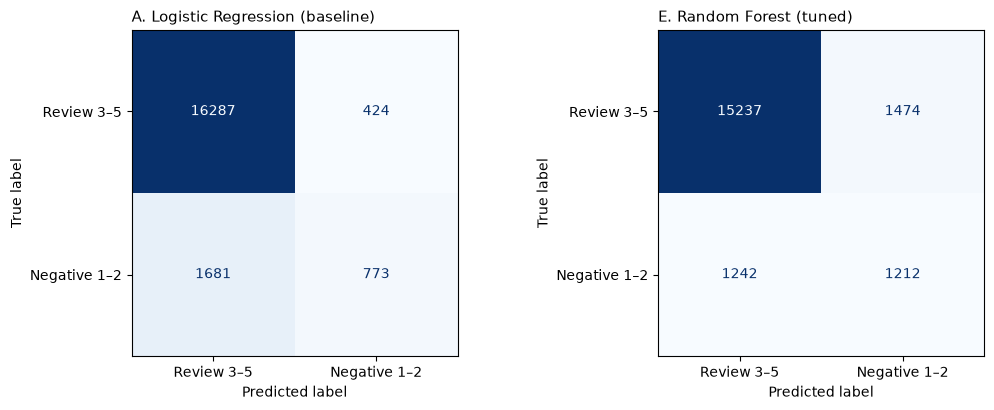

A. Logistic Regression (baseline): flags 1,197 of 19,165 orders. 773 of those are real negative reviews (65% of flags correct), catching 31% of all 2,454 negative reviews.
E. Random Forest (tuned): flags 2,686 of 19,165 orders. 1,212 of those are real negative reviews (45% of flags correct), catching 49% of all 2,454 negative reviews.


In [7]:
BASELINE = "A. Logistic Regression (baseline)"
FINAL = "E. Random Forest (tuned)"
labels = ["Review 3–5", "Negative 1–2"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, name in zip(axes, [BASELINE, FINAL]):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        (test_probability[name] >= THRESHOLD).astype(int),
        display_labels=labels,
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(name, loc="left", fontsize=11)
plt.tight_layout()
plt.show()

actual_negative = y_test.to_numpy() == 1
for name in [BASELINE, FINAL]:
    flagged = test_probability[name] >= THRESHOLD
    caught = int((flagged & actual_negative).sum())
    print(
        f"{name}: flags {flagged.sum():,} of {len(y_test):,} orders. "
        f"{caught:,} of those are real negative reviews ({caught / flagged.sum():.0%} of flags correct), "
        f"catching {caught / actual_negative.sum():.0%} of all {actual_negative.sum():,} negative reviews."
    )

### What the test set tells us

* **No surprises.** The tuned Random Forest scores F1 0.472 on the test set against 0.469 in cross-validation, so it was not over-tuned to the training folds.
* **Same rows confirmed.** Candidate A reproduces the Logistic Regression notebook's test results exactly (precision 0.646, recall 0.315, F1 0.423).
* **Tuned Random Forest vs Logistic Regression baseline, in orders.** The forest catches **1,212 instead of 773** negative reviews (49% instead of 31%). To do that it flags more orders (2,686 vs 1,197), so a smaller share of its flags are correct (45% vs 65%). That is the precision/recall trade-off. If the customer-experience team can only contact a few customers, Phase 3 can raise the cut-off to flag fewer, higher-risk orders.
* **Against the fair comparison (B, balanced Logistic Regression),** the forest is better at a similar recall: precision 0.451 vs 0.362, F1 0.472 vs 0.433, PR-AUC 0.477 vs 0.429. The improvement comes from the model itself (thresholds and combinations), not just from the class weighting.

## 8. What does the Random Forest rely on?

A Random Forest has no coefficients to read, so we use **permutation importance**.

**In plain words:** take one column in the test set (say `delivery_days`) and **shuffle it randomly** between orders, which breaks its link to the outcome. Then measure how much the model's PR-AUC drops. A big drop means the model relies on that column; no drop means it barely uses it. Each column is shuffled 5 times and the drops are averaged.

This works on the **original 21 columns** rather than the 169 one-hot columns, so it is easier to read than a coefficient table. It shows what the model *relies on*, not what *causes* negative reviews.

,feature,pr_auc_drop,spread_across_repeats
0,days_early,0.1009,0.0057
1,late_delivery_flag,0.0402,0.0033
2,delivery_days,0.0381,0.0037
3,item_count,0.0335,0.0012
4,customer_state,0.0075,0.0021
5,same_state,0.0049,0.0014
6,seller_count,0.0049,0.0007
7,primary_product_category,0.0046,0.0008
8,purchase_month,0.0035,0.0020
9,product_volume_cm3_mean,0.0022,0.0005


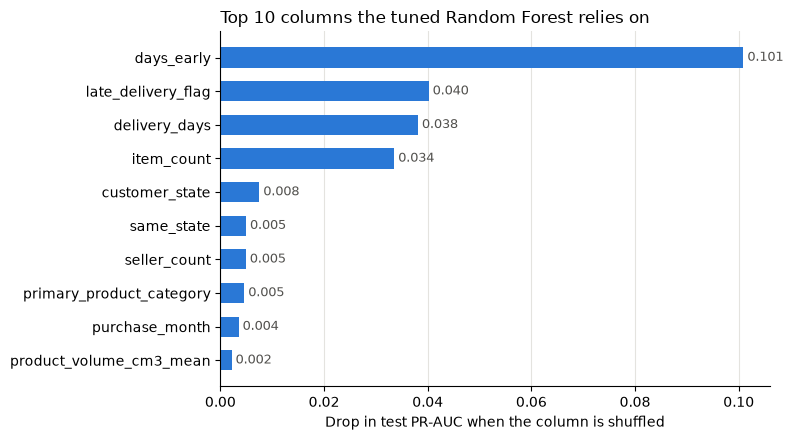

In [8]:
final_model = grid_search.best_estimator_
importance = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=5,
    random_state=RANDOM_SEED,
)
importance_table = (
    pd.DataFrame({
        "feature": X_test.columns,
        "pr_auc_drop": importance.importances_mean,
        "spread_across_repeats": importance.importances_std,
    })
    .sort_values("pr_auc_drop", ascending=False)
    .reset_index(drop=True)
)
display(importance_table.round(4))

top = importance_table.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(top["feature"], top["pr_auc_drop"], color="#2a78d6", height=0.6)
for bar, value in zip(bars, top["pr_auc_drop"]):
    ax.text(value, bar.get_y() + bar.get_height() / 2, f" {value:.3f}",
            va="center", fontsize=9, color="#52514e")
ax.set_xlabel("Drop in test PR-AUC when the column is shuffled")
ax.set_title("Top 10 columns the tuned Random Forest relies on", loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#e4e3df", linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### What the importance results tell us

* **Delivery against the promised date dominates.** `days_early` (positive = early, negative = late) is by far the column the forest relies on most: shuffling it cuts PR-AUC by about 0.10. `late_delivery_flag` and `delivery_days` come next, at about 0.04 each.
* **`item_count` is the strongest non-timing signal** (about 0.03), so multi-item orders carry more risk. One possible reason is that items in the same order can arrive separately or incomplete. That is a hypothesis to check in the data, not a finding.
* **Everything else adds little** (each under 0.01): customer state, same-state delivery, seller count, product category and month. Payment details and purchase weekday add essentially nothing; drops around zero are just noise.
* **Caution: the three timing columns overlap.** When one is shuffled, the other two still carry much of the same signal. So each one looks *less* important on its own than delivery timing really is as a group.
* **A different view from the Logistic Regression coefficients.** There, the largest coefficients belonged to individual product categories and states. A big coefficient on a rare category does not mean that column matters across all orders, and permutation importance measures exactly that.

## 9. Save the Random Forest for Phase 3

**In plain words:** the `.pkl` file stores the **whole fitted pipeline** (fill-in of missing values, one-hot encoding and the 200 trees) together with the 0.50 cut-off, the list of 21 input columns, and notes on how it was built. It is saved with the same team function as the Logistic Regression model, so Phase 3 can load **either** model with `predict_from_delivered_order_artifact(...)`. It uses a different file name, so the Logistic Regression `.pkl` is not overwritten.

200 deep trees make a much bigger file than one set of coefficients, so the file is saved **compressed** (`compress=3`) to stay under GitHub's 50 MB warning size. `joblib.load` opens it exactly the same way.

The last line reloads the file and scores one test order, to prove the saved file works on its own.

In [9]:
ARTIFACT_PATH = PROJECT_ROOT / "deployment" / "delivered_order_random_forest_pipeline.pkl"
best_settings = {
    key.replace("classifier__", ""): value for key, value in grid_search.best_params_.items()
}

save_delivered_order_inference_artifact(
    final_model,
    str(ARTIFACT_PATH),
    threshold=THRESHOLD,
    metadata={
        "training_data_contract": "Phase 1 order_level.csv + item_level.csv",
        "population": "all delivered orders with a recorded review",
        "model": "Random Forest",
        "hyperparameters": best_settings | {"n_estimators": 200},
        "selection": "GridSearchCV, 5-fold stratified CV on training data, refit on mean F1",
        "cv_f1": round(float(cv_table.loc[FINAL, "f1"]), 4),
        "test_metrics": {key: round(float(value), 4) for key, value in test_table.loc[FINAL].items()},
        "classification_threshold": THRESHOLD,
        "random_seed": RANDOM_SEED,
        "sklearn_version": sklearn.__version__,
    },
    compress=3,
)

artifact = joblib.load(ARTIFACT_PATH)
display(predict_from_delivered_order_artifact(artifact, X_test.iloc[[0]]))
print(f"Saved {ARTIFACT_PATH.relative_to(PROJECT_ROOT).as_posix()} "
      f"({ARTIFACT_PATH.stat().st_size / 1e6:.1f} MB)")
print(f"Notebook runtime: {(time.perf_counter() - notebook_started) / 60:.1f} minutes")

,negative_review_probability,predicted_negative_review
81243,0.257483,0


Saved deployment/delivered_order_random_forest_pipeline.pkl (22.8 MB)
Notebook runtime: 11.0 minutes


## 10. Summary for the Phase 2 report

### Model comparison (held-out test set: 19,165 orders, cut-off 0.50)

| Model | Family | CV F1 | Test precision | Test recall | Test F1 | Test PR-AUC | Test ROC-AUC |
|---|---|---|---|---|---|---|---|
| A. Logistic Regression (baseline) | Linear | 0.422 | 0.646 | 0.315 | 0.423 | 0.431 | 0.748 |
| B. Logistic Regression (balanced) | Linear | 0.433 | 0.362 | 0.538 | 0.433 | 0.429 | 0.753 |
| C. Decision Tree (default) | Tree | 0.321 | 0.317 | 0.343 | 0.330 | 0.193 | 0.617 |
| D. Random Forest (default) | Tree | 0.422 | 0.701 | 0.314 | 0.433 | 0.462 | 0.757 |
| **E. Random Forest (tuned)** | **Tree** | **0.469** | 0.451 | 0.494 | **0.472** | **0.477** | **0.764** |

Tuned settings: 200 trees, no depth limit, at least 10 orders per leaf, `class_weight="balanced_subsample"`. These were chosen by a 5-fold grid search over 12 combinations.

### Final selection: tuned Random Forest

1. It has the **best cross-validation F1**, by a margin well beyond fold-to-fold noise, and it was chosen **before** the test set was opened.
2. It has the **best ranking quality** (PR-AUC, ROC-AUC) on unseen orders.
3. It still **beats Logistic Regression when both get the same imbalance help**, so the gain comes from the model family.

Logistic Regression remains the simpler, easier-to-explain baseline.

### Actionable insights for the customer-experience team

* **Act right after delivery, starting with late orders.** How the delivery compares with the promised date is the strongest warning sign. Late orders are the obvious first queue for a proactive apology, voucher or check-in before the customer writes a review.
* **Watch multi-item orders.** After timing, the number of items is the clearest risk signal.
* **Size the cut-off to team capacity.** At 0.50 the model flags about 14% of delivered orders and catches about half of the negative reviews, with 45% of flags correct (13% would be correct by chance). A higher cut-off gives a shorter, more precise list.
* **Delivery is the lever the business controls.** Payment details and purchase weekday add essentially nothing, so effort is better spent on logistics and on keeping delivery promises realistic.

### Limitations

* **The risk score is not a true probability.** `balanced_subsample` makes negative reviews count about 7× more, which pushes scores upward. Use the output as a risk score for ranking. It would need calibration before anyone could say "a 30% chance".
* **Fixed 0.50 cut-off.** The cut-off was not tuned. A different cut-off trades precision for recall.
* **Slight optimism in the tuned CV score.** It is the best of 12 tries on the same folds. The untouched test set (F1 0.472) confirms the result holds.
* **The best setting is at the edge of the grid.** 10 was the smallest leaf size tried, so a follow-up grid could also test 5.
* **Only reviewed orders.** 99.3% of delivered orders have a review, so the model predicts negative-review risk *given that a review is written*.
* **The overall signal is moderate.** Even the best model misses about half of the negative reviews. Much of what makes a customer unhappy (product quality, expectations) is not in the data.
* **Associations, not causes.** Importance shows what the model relies on, not what causes negative reviews.
* **Model file size.** 200 deep trees make the `.pkl` much larger than the Logistic Regression file, even compressed (size printed in section 9).